In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
%matplotlib inline

companies=pd.read_csv(r'D:\kailas\ML\1000_Companies.csv')
x=companies.iloc[:,:-1].values
y=companies.iloc[:,4].values

companies.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Load the dataset
companies = pd.read_csv(r'D:\kailas\ML\1000_Companies.csv')

# Inspect the first few rows to understand the structure of the data
print(companies.head())

# Extract the features (X) and target variable (y)
# Assuming that 'State' is categorical and 'Profit' is the target variable.
X = companies[['R&D Spend', 'Administration', 'Marketing Spend', 'State']]  # Add all relevant features here
y = companies['Profit']

# Label encode the 'State' column if it is categorical
labelencoder = LabelEncoder()
X['State'] = labelencoder.fit_transform(X['State'])

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Create the Linear Regression model and train it
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Make predictions on the test set
y_pred = regressor.predict(X_test)

# Output the predictions (predicted profit)
print("Predictions on the Test Set: ")
print(y_pred)

# Evaluate the model - Calculate the R-squared value
print(f"R-squared on Test Set: {regressor.score(X_test, y_test)}")

# Calculate coefficients and intercept
print(f"Model Coefficients: {regressor.coef_}")
print(f"Model Intercept: {regressor.intercept_}")


   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Florida  191050.39
3  144372.41       118671.85        383199.62    New York  182901.99
4  142107.34        91391.77        366168.42     Florida  166187.94
Predictions on the Test Set: 
[ 89624.88499983  88261.44060358  94728.57723845 176034.49990954
  83234.84214495 110393.04058199 131831.18880607  91307.52461765
 164414.26754671  53585.35570743  66786.11950078 150921.89704628
 126746.78121459  59174.341725   177341.80724482  75139.98127599
 118605.9491146  164403.24374731 171336.34862472 181885.06087421
 118762.26624783  85504.5201526  181345.84072646  83979.76201107
 104839.00200137 101067.00608604  53722.31401539  56706.45386115
  68732.18107141 209811.34272095 121136.34391499 111557.54775873
 101309.70393418 138315.39958078  63

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_13064\388039468.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['State'] = labelencoder.fit_transform(X['State'])


In [15]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

# Load the dataset
companies = pd.read_csv(r'D:\kailas\ML\1000_Companies.csv')

# Convert the DataFrame to a NumPy array
x = companies.values

# Step 1: Apply LabelEncoder to the "State" column (column index 3)
labelencoder = LabelEncoder()
x[:, 3] = labelencoder.fit_transform(x[:, 3])

# Step 2: Apply OneHotEncoder to the transformed "State" column
ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(), [3])],
    remainder='passthrough'  # Leave other columns unchanged
)

# Perform transformation
x = ct.fit_transform(x)
 
# Display the first row of the transformed dataset

#print(x[0])

#dummy variable trap to remove 1st column(doesn't affect dataset)
x=x[:,1:]





In [17]:
#another method
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

# Load the dataset
companies = pd.read_csv(r'D:\kailas\ML\1000_Companies.csv')

# Convert the DataFrame to a NumPy array (optional, for compatibility)
x = companies.values

# Step 1: Use OneHotEncoder directly on the "State" column (column index 3)
# ColumnTransformer specifies which column to transform and leaves the rest untouched
ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(drop='first'), [3])],  # drop='first' to avoid dummy variable trap
    remainder='passthrough'  # Leave other columns unchanged
)

# Perform transformation
x = ct.fit_transform(x)

# Display the first row of the transformed dataset
print(x[0])


[0.0 1.0 165349.2 136897.8 471784.1 192261.83]


In [18]:
from sklearn.model_selection import train_test_split

#split the dataset into train and test
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=0)

In [19]:
#fitting multiple linear regressin to training set

from sklearn.linear_model import LinearRegression

regressor=LinearRegression()
regressor.fit(x_train,y_train)

LinearRegression()

In [20]:
#predict the test set results
y_pred=regressor.predict(x_test)
print(y_pred)


[ 89012.02672  87654.55773  94093.35179 175396.2616   83356.61784
 110395.794   105008.31     90687.2921  164180.2702   53483.75718
  66273.3533  150393.716   125971.2343   58694.93455 176344.525
  75297.23305 118219.3944  163462.6654  132602.65    181574.4968
  97483.56     84909.71956 180684.3252   83391.64379 104159.467
 100404.0021   64926.08     56944.49153  68210.88613 191792.06
 120738.6997  110848.5685  101352.2656  137842.4672   63306.39937
 107994.381   185502.5285  171176.9165  174364.2776  117645.3106
  96616.9285  164336.6055  106865.8621   50468.96294 116492.8715
  57992.70704 158208.7735   78689.62408 159514.1307  131051.7051
 184555.1194  174329.2516   92949.45565  78308.61013 180257.1795
  84583.38025 142762.3312  170174.8327   84305.73556 105154.7165
 141527.0259   52609.81711 140832.487   138872.7426   97478.0542
 113578.8837  126506.0207  151774.2509   58918.75889 174007.1838
 123690.2763  167934.0264   91370.72519 155791.1289   83553.10486
  77847.29279 120375.6258

In [25]:
correlation_matrix = pd.DataFrame(x).corr()
print(correlation_matrix)


          0         1         2         3         4         5
0  1.000000 -0.488033  0.029764 -0.009794  0.038872  0.016249
1 -0.488033  1.000000 -0.015930 -0.011197 -0.020495 -0.013040
2  0.029764 -0.015930  1.000000  0.582434  0.978407  0.945245
3 -0.009794 -0.011197  0.582434  1.000000  0.520465  0.741560
4  0.038872 -0.020495  0.978407  0.520465  1.000000  0.917270
5  0.016249 -0.013040  0.945245  0.741560  0.917270  1.000000


In [9]:
#calculating the intercept
print(regressor.intercept_)

-1.7462298274040222e-10


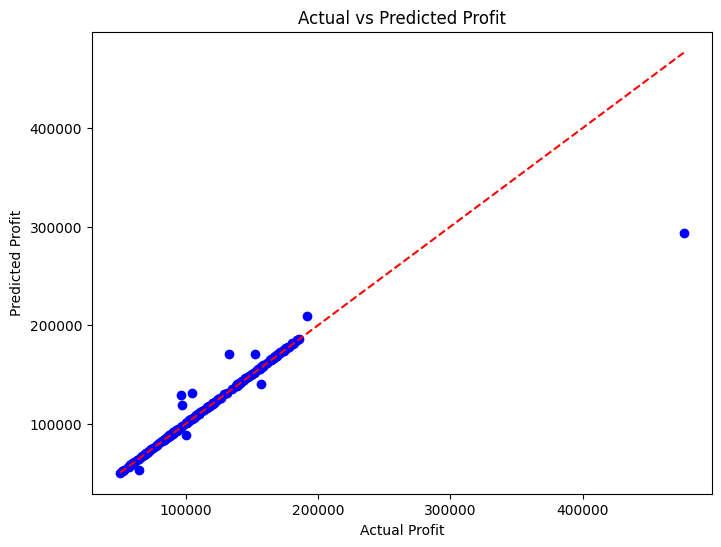

In [30]:
import matplotlib.pyplot as plt

# Create a scatter plot for actual vs predicted profit
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue')
plt.title('Actual vs Predicted Profit')
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')

# Add a line of perfect predictions (y = x)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')

plt.show()
